In [5]:
import re
import string
from collections import Counter
import pandas as pd
import spacy
import textstat

**Словарь Oxford 5000 с размеченными словами по уровням CEFR**

In [6]:
oxford_dict = pd.read_csv('oxford-5k.csv').set_index('word')['level'].to_dict()

**Импортируем модель spaCy для английского языка**

In [7]:
nlp = spacy.load("en_core_web_sm")

**Функция для анализа текста**
- Общее количество слов
- Средняя длина слов
- Количество уникальных слов
- Лексическое разнообразие
- Подсчёт слов по уровням
- Подсчёт сложных конструкций

In [8]:
def analyze_text(text):
    #предварительная обработка текста
    text = text.lower()
    #удаляем пунктуацию
    text_clean = text.translate(str.maketrans('', '', string.punctuation))
    words = text_clean.split()
    sentences = re.split(r'[.!?]+', text)
    sentences = [s for s in sentences if s.strip()]  # Убираем пустые строки

    #1.общее количество слов
    total_words = len(words)

    #2.средняя длина слова
    if total_words > 0:
        avg_word_length = sum(len(word) for word in words) / total_words
    else:
        avg_word_length = 0

    #3.словарный запас (количество уникальных слов)
    unique_words = set(words)
    vocabulary_size = len(unique_words)

    #4.лексическое разнообразие (отношение уникальных слов к общему числу)
    if total_words > 0:
        lexical_diversity = vocabulary_size / total_words
    else:
        lexical_diversity = 0

    #5.подсчёт слов по уровням
    level_counts = {'a1': 0, 'a2': 0, 'b1': 0, 'b2': 0, 'c1': 0, 'c2': 0}
    for word in words:
        if word in oxford_dict:
            level = oxford_dict[word]
            if level in level_counts:
                level_counts[level] += 1
    
    #вычисляем доли
    if total_words > 0:
        for level in level_counts:
            level_counts[level] = round(level_counts[level] / total_words, 2)

        doc = nlp(text)

    #6.считаем сложные конструкции
    complex_sentences = 0
    passive_constructions = 0

    for sent in doc.sents:
        #признаки сложного предложения (подчинительные союзы, относительные местоимения)
        has_subordinate = any(token.dep_ in ['mark', 'advcl'] for token in sent)
        has_relative = any(token.dep_ == 'relcl' for token in sent)

        if has_subordinate or has_relative:
            complex_sentences += 1

        #пассивный залог
        for token in sent:
            if token.tag_ == 'VBN' and token.head.lemma_ == 'be':
                passive_constructions += 1

    #результаты
    results = {
        'total_words': total_words,
        'avg_word_length': round(avg_word_length, 2),
        'A1_level_words': level_counts['a1'],
        'A2_level_words': level_counts['a2'],
        'B1_level_words': level_counts['b1'],
        'B2_level_words': level_counts['b2'],
        'C1_level_words': level_counts['c1'],
        'C2_level_words': level_counts['c2'],
        'vocabulary_size': vocabulary_size,
        'lexical_diversity': round(lexical_diversity, 2),
        'complex_sentence_ratio': complex_sentences / len(list(doc.sents)) if doc.sents else 0,
        'passive_voice_ratio': passive_constructions / total_words if total_words else 0,
        'flesch_reading_ease': textstat.flesch_reading_ease(text),
        'smog_index': textstat.smog_index(text),
        'coleman_liau_index': textstat.coleman_liau_index(text),
        'sentence_count': textstat.sentence_count(text),
        'lexicon_count': textstat.lexicon_count(text, removepunct=True)
    }
    return results

**Функция оценки уровня**

In [9]:
def estimate_level(results):
    score = 0
    #лексика
    if results['B2_level_words'] >= 0.05 or results['C1_level_words'] >= 0.03 or results['C2_level_words'] >= 0.01:
        score += 2
    elif results['B1_level_words'] >= 0.1:
        score += 1

    #грамматика
    if results.get('complex_sentence_ratio', 0) >= 0.3:
        score += 3
    if results.get('passive_voice_ratio', 0) > 0.02:
        score += 1

    #cтилистика
    if results.get('flesch_reading_ease', 100) >= 60:  # Более сложный текст
        score += 1

    #традиционные метрики
    if results['avg_word_length'] > 4.8:
        score += 1
    if results['lexical_diversity'] >= 0.5:
        score += 1
    print(score)
    #классификация
    if score <= 2:
        return "A1-A2 (Beginner)"
    elif score <= 4:
        return "B1 (Intermediate)"
    elif score <= 6:
        return "B2 (Upper-Intermediate)"
    else:
        return "C1-C2 (Advanced)"

**Блок для чтения текста из файла**

In [ ]:
"""
def read_text_from_file(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            text = file.read()
        return text
    except FileNotFoundError:
        print(f"Ошибка: Файл '{file_path}' не найден.")
        return
    except Exception as e:
        print(f"Произошла ошибка при чтении файла: {e}")
        return 
    
file_path = "C:/Users/boss/Documents/examples/C1_example.txt"  # Укажите путь к вашему файлу
text_from_file = read_text_from_file(file_path)

if text_from_file:  # Если файл успешно прочитан
    analysis = analyze_text(text_from_file)
    level = estimate_level(analysis)

    print("Результаты анализа текста из файла:")
    for key, value in analysis.items():
        print(f"{key}: {value}")
    print(f"\nОценочный уровень английского: {level}")
"""

*Датасет с размеченными текста по CEFR (cefr_leveled_texts.csv)*

**Функция для анализа текстов из датасета**
- Чтение CSV файла
- Маппинг уровней для сравнения
- Анализ текста (analyze_text)
- Определение уровня и сравнение с правильным ответом
- Сохраняем результаты в results_df

In [ ]:
def analyze_csv_texts(csv_file_path):
    #чтение CSV файла
    try:
        df = pd.read_csv(csv_file_path)
    except Exception as e:
        print(f"Ошибка при чтении CSV файла: {e}")
        return None
    
    #список для хранения результатов
    results_list = []
    
    #маппинг уровней для сравнения
    level_mapping = {
        'A1': 'A1-A2 (Beginner)',
        'A2': 'A1-A2 (Beginner)',
        'B1': 'B1 (Intermediate)',
        'B2': 'B2 (Upper-Intermediate)',
        'C1': 'C1-C2 (Advanced)',
        'C2': 'C1-C2 (Advanced)'
    }
    
    #анализ каждого текста
    for idx, row in df.iterrows():
        text = row['text']
        real_level = row['label']
        
        #проверка, что текст не пустой
        if pd.isna(text) or str(text).strip() == '':
            print(f"\nТекст {idx+1}: ПРОПУЩЕН (пустой текст)")
            continue
        
        #анализ текста
        analysis = analyze_text(str(text))
        estimated_level = estimate_level(analysis)
        
        #определение ожидаемого уровня в формате оценки
        expected_level = level_mapping.get(real_level.upper(), "Unknown")
        
        #сравнение
        is_correct = (estimated_level == expected_level)
        
        #сохранение результатов
        results_list.append({
            'text_id': idx + 1,
            'real_level': real_level,
            'estimated_level': estimated_level,
            'expected_level': expected_level,
            'is_correct': is_correct,
            **analysis
        })
    
    #сводная статистика
    if results_list:
        
        results_df = pd.DataFrame(results_list)
        
        #общая точность
        accuracy = results_df['is_correct'].mean() * 100
        print(f"\nОбщая точность: {accuracy:.1f}% ({results_df['is_correct'].sum()}/{len(results_df)})")
        
        #точность по уровням
        print("\nТочность по уровням:")
        for level in ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']:
            level_data = results_df[results_df['real_level'].str.upper() == level]
            if len(level_data) > 0:
                level_accuracy = level_data['is_correct'].mean() * 100
                print(f"  {level}: {level_accuracy:.1f}% ({level_data['is_correct'].sum()}/{len(level_data)})")
        
        return results_df
    
    return None

In [ ]:
csv_file_path = "C:/Users/boss/Documents/Althaea/hotter than hell/КУРСОВАЯ/project/cefr_leveled_texts.csv"
results_df = analyze_csv_texts(csv_file_path)


--- Текст 1 ---
Реальный уровень: B2
7

--- Текст 2 ---
Реальный уровень: B2
5

--- Текст 3 ---
Реальный уровень: B2
7

--- Текст 4 ---
Реальный уровень: B2
5

--- Текст 5 ---
Реальный уровень: B2
5

--- Текст 6 ---
Реальный уровень: B2
1

--- Текст 7 ---
Реальный уровень: B2
4

--- Текст 8 ---
Реальный уровень: B2
4

--- Текст 9 ---
Реальный уровень: B2
7

--- Текст 10 ---
Реальный уровень: B2
6

--- Текст 11 ---
Реальный уровень: B2
3

--- Текст 12 ---
Реальный уровень: B2
4

--- Текст 13 ---
Реальный уровень: B2
5

--- Текст 14 ---
Реальный уровень: B2
5

--- Текст 15 ---
Реальный уровень: B2
7

--- Текст 16 ---
Реальный уровень: B2
5

--- Текст 17 ---
Реальный уровень: B2
7

--- Текст 18 ---
Реальный уровень: B2
5

--- Текст 19 ---
Реальный уровень: B2
5

--- Текст 20 ---
Реальный уровень: B2
4

--- Текст 21 ---
Реальный уровень: B2
6

--- Текст 22 ---
Реальный уровень: B2
4

--- Текст 23 ---
Реальный уровень: B2
4

--- Текст 24 ---
Реальный уровень: B2
4

--- Текст 25 ---
Реальны

KeyboardInterrupt: 

**Вывод, сколько верно и неверно определённых текстов**

In [31]:
if results_df is not None:
    correct = (results_df['estimated_level'] == results_df['expected_level']).sum()
    incorrect = (results_df['estimated_level'] != results_df['expected_level']).sum()
    total = len(results_df)

    print(f"\nРезультаты:")
    print(f"Правильно: {correct}/{total} ({correct/total*100:.1f}%)")
    print(f"Неправильно: {incorrect}/{total} ({incorrect/total*100:.1f}%)")


Результаты:
Правильно: 677/1494 (45.3%)
Неправильно: 817/1494 (54.7%)


# Графики

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

C:\Users\boss\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\boss\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



4. МАТРИЦА ОШИБОК (Сравнение реальных и предсказанных уровней)


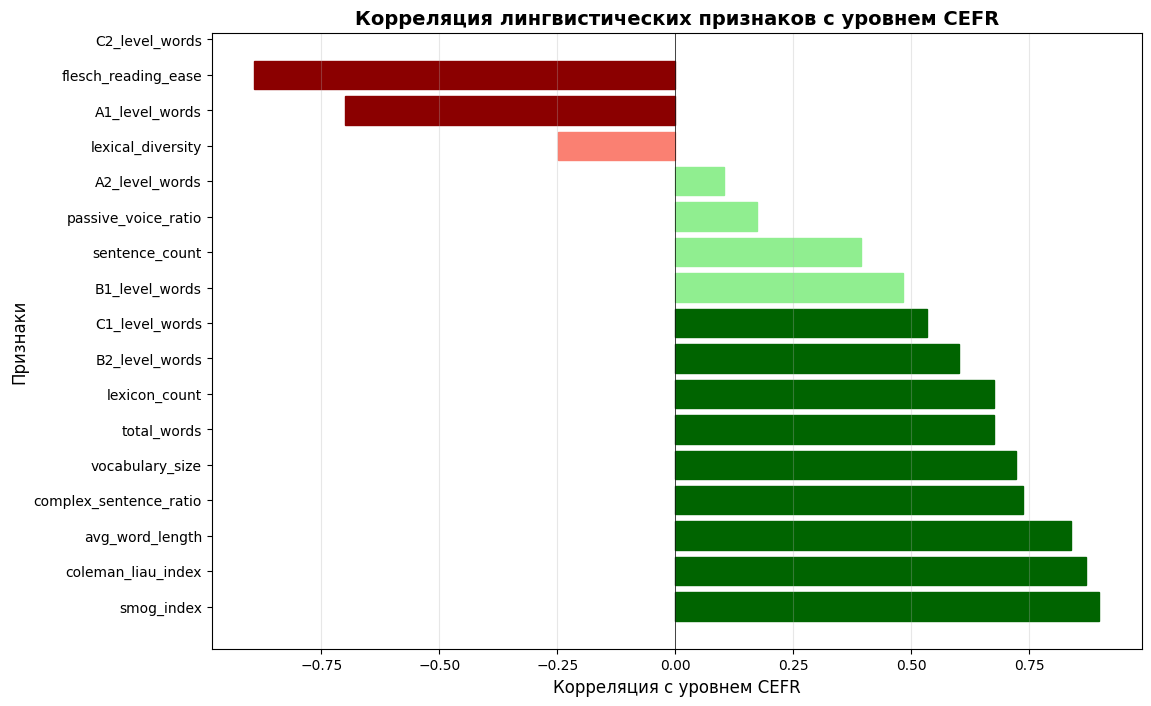

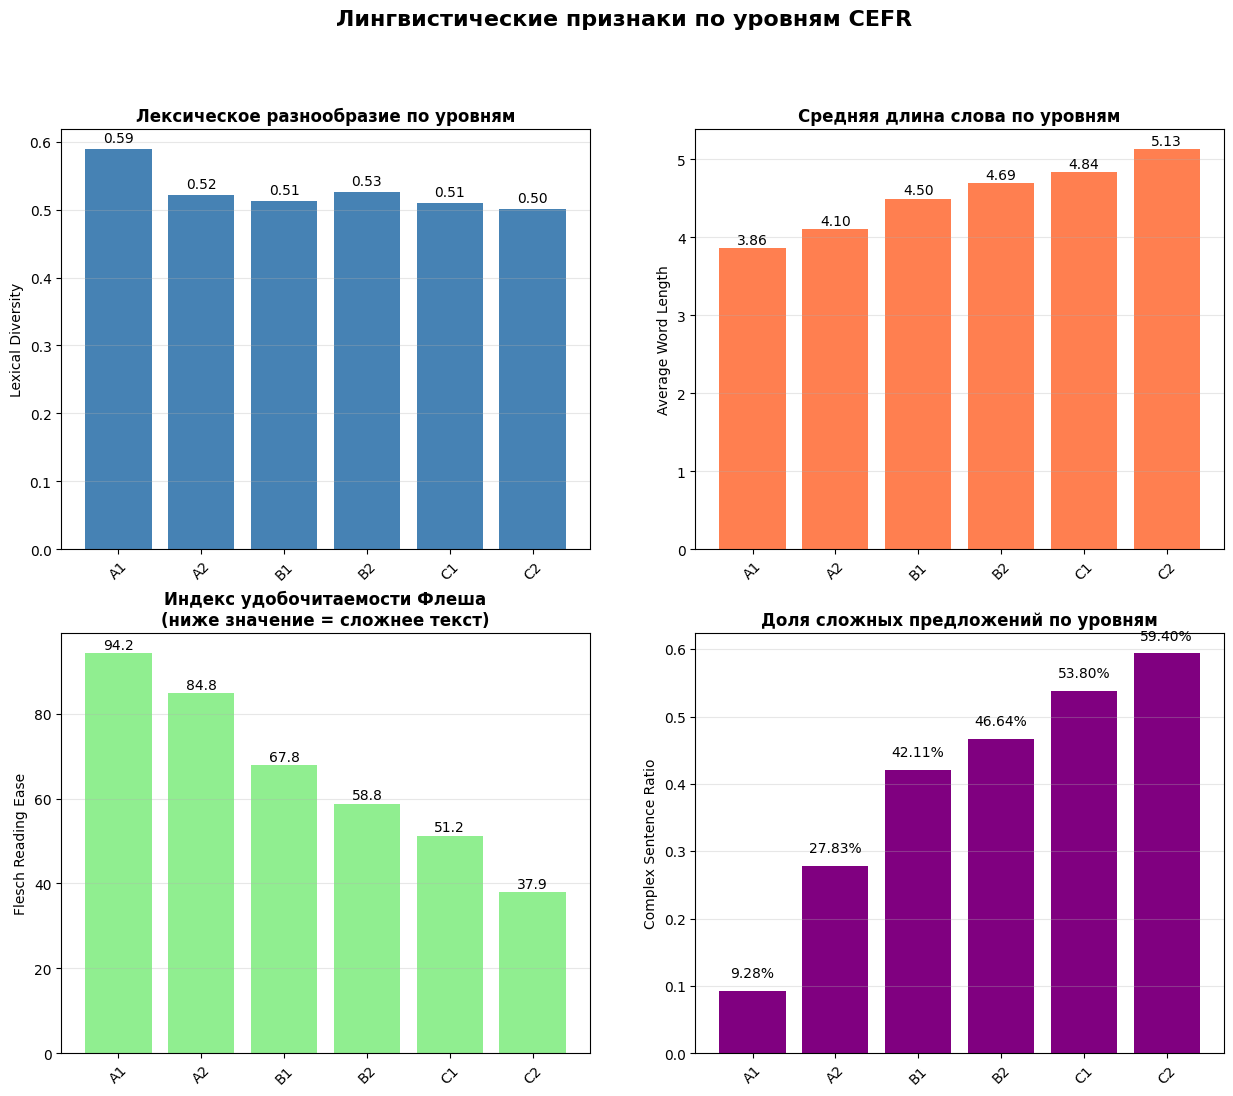

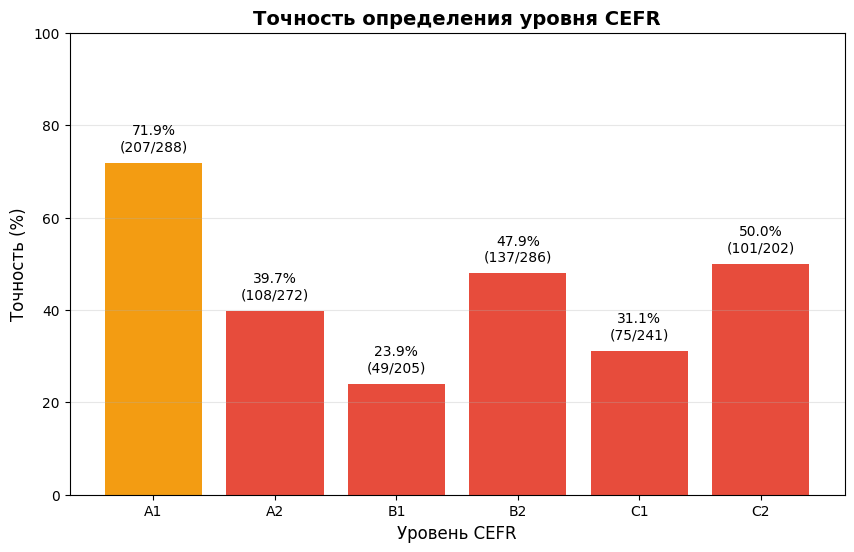

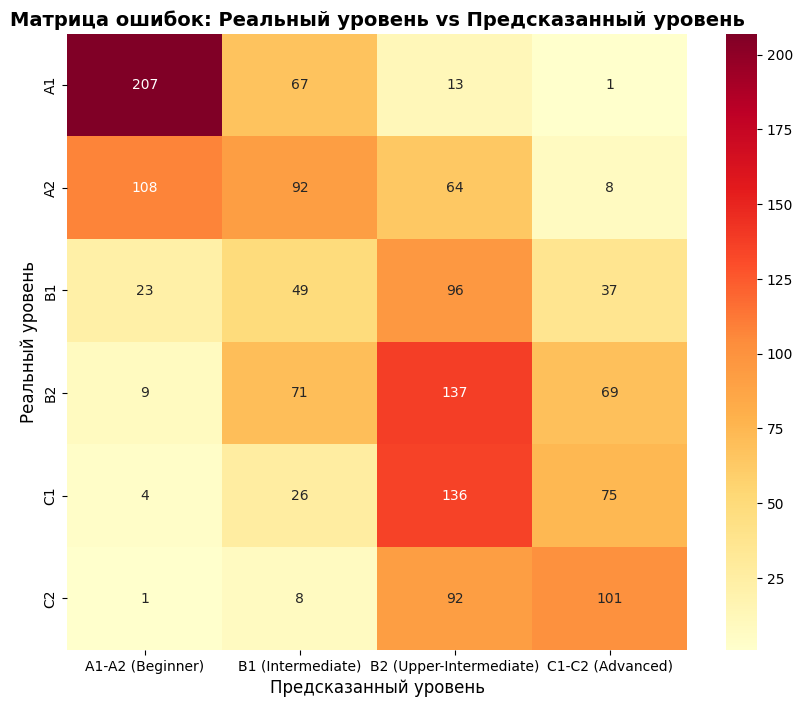

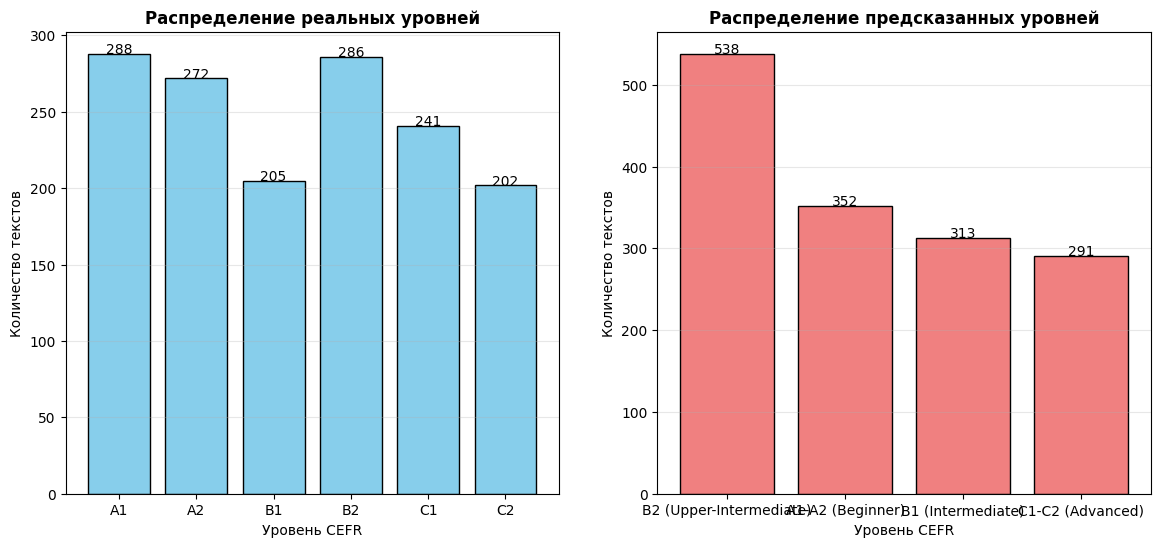

In [32]:
plt.style.use('default')
sns.set_palette("husl")

#1) график корреляции признаков с уровнем CEFR
if results_df is not None:
    #преобразуем реальные уровни в числовые значения для корреляции
    cefr_numeric_mapping = {'A1': 1, 'A2': 2, 'B1': 3, 'B2': 4, 'C1': 5, 'C2': 6}
    results_df['cefr_numeric'] = results_df['real_level'].map(cefr_numeric_mapping)
    
    #признаки для анализа корреляции
    feature_columns = ['total_words', 'avg_word_length', 'A1_level_words', 'A2_level_words',
                       'B1_level_words', 'B2_level_words', 'C1_level_words', 'C2_level_words',
                       'vocabulary_size', 'lexical_diversity', 'complex_sentence_ratio',
                       'passive_voice_ratio', 'flesch_reading_ease', 'smog_index',
                       'coleman_liau_index', 'sentence_count', 'lexicon_count']
    
    #вычисляем корреляцию каждого признака с CEFR уровнем
    correlations = {}
    for feature in feature_columns:
        if feature in results_df.columns:
            correlations[feature] = results_df[feature].corr(results_df['cefr_numeric'])
    
    #создаем DataFrame с корреляциями
    corr_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Correlation_with_CEFR'])
    corr_df = corr_df.sort_values('Correlation_with_CEFR', ascending=False)
    
    #визуализация корреляций
    plt.figure(figsize=(12, 8))
    bars = plt.barh(corr_df['Feature'], corr_df['Correlation_with_CEFR'])
    plt.xlabel('Корреляция с уровнем CEFR', fontsize=12)
    plt.ylabel('Признаки', fontsize=12)
    plt.title('Корреляция лингвистических признаков с уровнем CEFR', fontsize=14, fontweight='bold')
    
    #цветовая кодировка столбцов
    for i, (bar, corr_value) in enumerate(zip(bars, corr_df['Correlation_with_CEFR'])):
        if corr_value > 0.5:
            bar.set_color('darkgreen')
        elif corr_value > 0:
            bar.set_color('lightgreen')
        elif corr_value > -0.3:
            bar.set_color('salmon')
        else:
            bar.set_color('darkred')
    
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.grid(axis='x', alpha=0.3)
    plt.savefig('correlation_analysis.png', dpi=300, bbox_inches='tight')
    
    #2) сравнение признаков по уровням
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Лингвистические признаки по уровням CEFR', fontsize=16, fontweight='bold')
    
    #лексическое разнообразие по уровням
    if 'lexical_diversity' in results_df.columns:
        #группировка по реальным уровням
        level_lexical = results_df.groupby('real_level')['lexical_diversity'].mean()
        axes[0, 0].bar(range(len(level_lexical)), level_lexical.values, color='steelblue')
        axes[0, 0].set_xticks(range(len(level_lexical)))
        axes[0, 0].set_xticklabels(level_lexical.index, rotation=45)
        axes[0, 0].set_title('Лексическое разнообразие по уровням', fontsize=12, fontweight='bold')
        axes[0, 0].set_ylabel('Lexical Diversity')
        axes[0, 0].grid(axis='y', alpha=0.3)
        #добавление значений на столбцы
        for i, v in enumerate(level_lexical.values):
            axes[0, 0].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10)
    
    #средняя длина слова по уровням
    if 'avg_word_length' in results_df.columns:
        level_word_len = results_df.groupby('real_level')['avg_word_length'].mean()
        axes[0, 1].bar(range(len(level_word_len)), level_word_len.values, color='coral')
        axes[0, 1].set_xticks(range(len(level_word_len)))
        axes[0, 1].set_xticklabels(level_word_len.index, rotation=45)
        axes[0, 1].set_title('Средняя длина слова по уровням', fontsize=12, fontweight='bold')
        axes[0, 1].set_ylabel('Average Word Length')
        axes[0, 1].grid(axis='y', alpha=0.3)
        for i, v in enumerate(level_word_len.values):
            axes[0, 1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10)
    
    #индекс удобочитаемости по уровням
    if 'flesch_reading_ease' in results_df.columns:
        level_flesch = results_df.groupby('real_level')['flesch_reading_ease'].mean()
        axes[1, 0].bar(range(len(level_flesch)), level_flesch.values, color='lightgreen')
        axes[1, 0].set_xticks(range(len(level_flesch)))
        axes[1, 0].set_xticklabels(level_flesch.index, rotation=45)
        axes[1, 0].set_title('Индекс удобочитаемости Флеша\n(ниже значение = сложнее текст)', fontsize=12, fontweight='bold')
        axes[1, 0].set_ylabel('Flesch Reading Ease')
        axes[1, 0].grid(axis='y', alpha=0.3)
        for i, v in enumerate(level_flesch.values):
            axes[1, 0].text(i, v + 1, f'{v:.1f}', ha='center', fontsize=10)
    
    #доля сложных предложений по уровням
    if 'complex_sentence_ratio' in results_df.columns:
        level_complex = results_df.groupby('real_level')['complex_sentence_ratio'].mean()
        axes[1, 1].bar(range(len(level_complex)), level_complex.values, color='purple')
        axes[1, 1].set_xticks(range(len(level_complex)))
        axes[1, 1].set_xticklabels(level_complex.index, rotation=45)
        axes[1, 1].set_title('Доля сложных предложений по уровням', fontsize=12, fontweight='bold')
        axes[1, 1].set_ylabel('Complex Sentence Ratio')
        axes[1, 1].grid(axis='y', alpha=0.3)
        for i, v in enumerate(level_complex.values):
            axes[1, 1].text(i, v + 0.02, f'{v:.2%}', ha='center', fontsize=10)
    plt.savefig('features_by_level.png', dpi=300, bbox_inches='tight')
    
    #3) график точности по уровням
    #вычисление точности для каждого реального уровня
    accuracy_by_level = []
    for level in sorted(results_df['real_level'].unique()):
        level_data = results_df[results_df['real_level'] == level]
        correct = (level_data['estimated_level'] == level_data['expected_level']).sum()
        total = len(level_data)
        accuracy = (correct / total) * 100 if total > 0 else 0
        accuracy_by_level.append({
            'level': level,
            'accuracy': accuracy,
            'correct': correct,
            'total': total
        })
    
    accuracy_df = pd.DataFrame(accuracy_by_level)
    
    #визуализация точности
    plt.figure(figsize=(10, 6))
    bars = plt.bar(accuracy_df['level'], accuracy_df['accuracy'], 
                   color=['#2ecc71' if acc >= 80 else '#f39c12' if acc >= 60 else '#e74c3c' 
                          for acc in accuracy_df['accuracy']])
    plt.xlabel('Уровень CEFR', fontsize=12)
    plt.ylabel('Точность (%)', fontsize=12)
    plt.title('Точность определения уровня CEFR', fontsize=14, fontweight='bold')
    plt.ylim(0, 100)
    plt.grid(axis='y', alpha=0.3)
    
    #добавление значений на столбцы
    for bar, acc, corr, total in zip(bars, accuracy_df['accuracy'], accuracy_df['correct'], accuracy_df['total']):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 2,
                 f'{acc:.1f}%\n({corr}/{total})', ha='center', va='bottom', fontsize=10)
    plt.savefig('accuracy_by_level.png', dpi=300, bbox_inches='tight')
    
    #4) матрица ошибок
    print("\n" + "="*80)
    print("4. МАТРИЦА ОШИБОК (Сравнение реальных и предсказанных уровней)")
    print("="*80)
    
    #создание матрицы ошибок
    confusion_matrix = pd.crosstab(
        results_df['real_level'],
        results_df['estimated_level'],
        rownames=['Реальный уровень'],
        colnames=['Предсказанный уровень']
    )
    
    #визуализация матрицы ошибок
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='YlOrRd', 
                xticklabels=True, yticklabels=True)
    plt.title('Матрица ошибок: Реальный уровень vs Предсказанный уровень', fontsize=14, fontweight='bold')
    plt.xlabel('Предсказанный уровень', fontsize=12)
    plt.ylabel('Реальный уровень', fontsize=12)
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    
    #5) распределение оценок по уровням
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    #распределение реальных уровней
    real_counts = results_df['real_level'].value_counts().sort_index()
    ax1.bar(real_counts.index, real_counts.values, color='skyblue', edgecolor='black')
    ax1.set_title('Распределение реальных уровней', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Уровень CEFR')
    ax1.set_ylabel('Количество текстов')
    ax1.grid(axis='y', alpha=0.3)
    for i, (level, count) in enumerate(real_counts.items()):
        ax1.text(i, count + 0.1, str(count), ha='center', fontsize=10)
    
    #распределение предсказанных уровней
    pred_counts = results_df['estimated_level'].value_counts()
    ax2.bar(pred_counts.index, pred_counts.values, color='lightcoral', edgecolor='black')
    ax2.set_title('Распределение предсказанных уровней', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Уровень CEFR')
    ax2.set_ylabel('Количество текстов')
    ax2.grid(axis='y', alpha=0.3)
    for i, (level, count) in enumerate(pred_counts.items()):
        ax2.text(i, count + 0.1, str(count), ha='center', fontsize=10)
    plt.savefig('level_distribution.png', dpi=300, bbox_inches='tight')